In [1]:
print("Anirban")

Anirban


In [2]:
from langgraph.graph import START, END, StateGraph
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
from pydantic import BaseModel
from typing import TypedDict
import os
import time
import json


In [3]:
load_dotenv()

True

In [4]:
llm = HuggingFaceEndpoint(
    repo_id='meta-llama/Llama-3.1-8B-Instruct',
    huggingfacehub_api_token=os.getenv('HF_TOKEN')
)
model = ChatHuggingFace(llm = llm)

In [5]:
class GraphState(TypedDict):
    joke : str
    explaination : str
    topic : str

In [6]:
def create_joke(state:GraphState):
    template = """
        you are a very good comedian  Crack a joke on this given topic.
        
        topic : {topic}
    """

    prompt = ChatPromptTemplate.from_template(template=template)

    message = prompt.invoke({
        'topic' : state['topic']
    })

    response = model.invoke(message)
    
    return {'joke': response.content}



def explain_joke(state : GraphState):
    template = """
        you are a very joke explaination system. Explain the given joke.
        
        joke : {joke}
    """

    prompt = ChatPromptTemplate.from_template(template=template)

    message = prompt.invoke({
        'joke' : state['topic']
    })

    response = model.invoke(message)

    return {'explaination' : response.content}



In [7]:
graph = StateGraph(GraphState)
check_pointer = MemorySaver()

graph.add_node('create_joke', create_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'create_joke')
graph.add_edge('create_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

workflow = graph.compile(checkpointer=check_pointer)


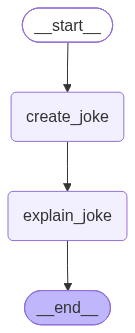

In [8]:
workflow

In [13]:

config1 = {
    'configurable' : {
        'thread_id' : 1
    }
}
config2 = {
    'configurable' : {
        'thread_id' : 2
    }
}

input = {
    'topic' : "pizza"
}

final_state = workflow.invoke(input=input, config=config2)

In [14]:
final_state

{'joke': 'Here\'s one:\n\n"You know what\'s weird about pizza? It\'s the only food where you can be in a relationship with someone for 5 years, and then break up with them in 5 minutes... because you ate them! (get it? eat... pizza... ahhaha)',
 'explaination': 'You want to know the punchline to the joke "pizza"? Well, I\'ve got a slice of a joke for you!\n\nThe joke is a play on expectations. Typically, a joke has a setup and a punchline. But in this case, the joke is just... "pizza". There\'s no punchline, no surprise, no clever twist. It\'s just a simple statement.\n\nThe humor comes from the absurdity of presenting a joke that doesn\'t follow the traditional joke structure. It\'s like walking into a comedy club and being told to laugh at the mere existence of a pizza. The joke is poking fun at the idea of what a joke should be, and that\'s the joke! (Sorry, I had to.)\n\nIn short, the joke "pizza" is a joke about not being a joke. It\'s a meta-joke, a joke about jokes. It\'s a chee

In [15]:
workflow.get_state(config=config2).values

{'joke': 'Here\'s one:\n\n"You know what\'s weird about pizza? It\'s the only food where you can be in a relationship with someone for 5 years, and then break up with them in 5 minutes... because you ate them! (get it? eat... pizza... ahhaha)',
 'explaination': 'You want to know the punchline to the joke "pizza"? Well, I\'ve got a slice of a joke for you!\n\nThe joke is a play on expectations. Typically, a joke has a setup and a punchline. But in this case, the joke is just... "pizza". There\'s no punchline, no surprise, no clever twist. It\'s just a simple statement.\n\nThe humor comes from the absurdity of presenting a joke that doesn\'t follow the traditional joke structure. It\'s like walking into a comedy club and being told to laugh at the mere existence of a pizza. The joke is poking fun at the idea of what a joke should be, and that\'s the joke! (Sorry, I had to.)\n\nIn short, the joke "pizza" is a joke about not being a joke. It\'s a meta-joke, a joke about jokes. It\'s a chee

In [18]:
workflow.get_state(config=config1).values

{'joke': 'Here\'s one:\n\nWhy did the pasta go to therapy?\n\nBecause it was feeling a little "drained" and couldn\'t "knead" any support! (get it? knead, like kneading dough... ahh, pasta puns!)',
 'explaination': 'OH NO, I\'M FED A JOKE THAT\'S AS SIMPLE AS A PASTA SAUCE RECIPE!\n\nOkay, let me try to break it down (pun intended).\n\nIt seems we have a joke that\'s just... "pasta." Like, that\'s it. No setup, no punchline, no context. It\'s just a word.\n\nI\'m going to take a wild guess here: is the joke that it\'s so simple, so straightforward, that it\'s almost like... a no-brainer? A joke so basic, it\'s like the punchline is "it\'s just pasta"! (ba-dum-tss)\n\nAm I right? Or am I just left with a plate of dry, unseasoned noodles? (Sorry, had to!)',
 'topic': 'pasta'}

In [16]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'joke': 'Here\'s one:\n\n"You know what\'s weird about pizza? It\'s the only food where you can be in a relationship with someone for 5 years, and then break up with them in 5 minutes... because you ate them! (get it? eat... pizza... ahhaha)', 'explaination': 'You want to know the punchline to the joke "pizza"? Well, I\'ve got a slice of a joke for you!\n\nThe joke is a play on expectations. Typically, a joke has a setup and a punchline. But in this case, the joke is just... "pizza". There\'s no punchline, no surprise, no clever twist. It\'s just a simple statement.\n\nThe humor comes from the absurdity of presenting a joke that doesn\'t follow the traditional joke structure. It\'s like walking into a comedy club and being told to laugh at the mere existence of a pizza. The joke is poking fun at the idea of what a joke should be, and that\'s the joke! (Sorry, I had to.)\n\nIn short, the joke "pizza" is a joke about not being a joke. It\'s a meta-joke, a joke abou